In [1]:
import itertools
import pickle
import random
import torch
from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torchvision.transforms import v2, transforms
from torch.utils.data import DataLoader, Dataset

## Device & Seeds

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(88)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(88)
np.random.seed(88)
random.seed(88)

## Dataset definition

In [3]:
(0.5,)*8

(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5)

In [4]:
def get_transform(nc, convert=True):
    transform_list = []
    grayscale = (nc == 1)
    if grayscale:
        transform_list.append(transforms.Grayscale(nc))
    if convert:
        transform_list += [transforms.ToTensor()]
        if grayscale:
            transform_list += [transforms.Normalize((0.5,), (0.5,))]
        else:
            transform_list += [transforms.Normalize((0.5,)*nc, (0.5,)*nc)]
    return transforms.Compose(transform_list)

class RainfallDataset(Dataset):
    def __init__(self, pickle_file_A, pickle_file_B, input_nc, output_nc) -> None:
        super().__init__()
        self.dir_A = pickle_file_A
        self.dir_B = pickle_file_B

        with open(self.dir_A, "rb") as f:
            data_A = pickle.load(f)
            self.A_images = list(data_A.values())
        with open(self.dir_B, "rb") as f:
            data_B = pickle.load(f)
            self.B_images = list(data_B.values())

        self.A_size = len(self.A_images)
        self.B_size = len(self.B_images)
        self.transform_A = get_transform(input_nc)
        self.transform_B = get_transform(output_nc)

    def __len__(self):
        return max(self.A_size, self.B_size)

    def __getitem__(self, index):
        idx_A = index % self.A_size
        idx_B = index % self.B_size

        A_np = self.A_images[idx_A]
        B_np = self.B_images[idx_B]

        # Handle stored lists like A_image[2] if needed
        # if isinstance(A_np, (list, tuple)) and len(A_np) > 2:
        #     A_np = A_np[2]

        # Convert to tensor
        # A_tensor = torch.from_numpy(A_np).unsqueeze(dim=0).float()
        # B_tensor = torch.from_numpy(B_np).unsqueeze(dim=0).float()
        A_img = Image.fromarray(A_np)
        B_img = Image.fromarray(B_np)

        A = self.transform_A(A_img)
        B = self.transform_B(B_img)

        # log_A = torch.log1p(A_tensor)
        # log_B = torch.log1p(B_tensor)

        # If data is (H, W, C), make it (C, H, W)
        # if A.ndim == 3 and A.shape[0] != 1 and A.shape[0] < A.shape[-1]:
        #     A = A.permute(2, 0, 1)
        # if B.ndim == 3 and B.shape[0] != 1 and B.shape[0] < B.shape[-1]:
        #     B = B.permute(2, 0, 1)

        # Normalize from [0, 255] → [-1, 1]
        # A = (A / 127.5) - 1.0
        # B = (B / 127.5) - 1.0

        # A = (A_tensor / 127.5) - 1.0
        # B = (B_tensor / 127.5) - 1.0
        # max_log_A = log_A.max()  # or e.g., 8 or 10 depending on your domain
        # max_log_B = log_B.max()
        # norm_A = (log_A / max_log_A) * 2.0 - 1.0
        # norm_B = (log_B / max_log_B) * 2.0 - 1.0
        # A = self.transform_A(A_tensor)
        # B = self.transform_B(B_tensor)
        return A, B#, max_log_A, max_log_B
# dataset = RainfallDataset(PICKLE_FILE_PATH_A, PICKLE_FILE_PATH_B, INPUT_NC, OUTPUT_NC)
# dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
# for A, B in dataloader:
#     print(A.shape, B.shape)
#     print(A[0].min(), A[0].max(), B[0].min(), B[0].max())
#     break

## CycleGAN Generator

In [5]:
# ------------------------------
# Norm Layer Helper (InstanceNorm per CycleGAN)
# ------------------------------
def get_norm(channels):
    return nn.InstanceNorm2d(channels, affine=False, track_running_stats=False)

# ------------------------------
# Resnet Block (with InstanceNorm)
# ------------------------------
class ResnetBlock(nn.Module):
    def __init__(self, dim, padding_type="reflect", use_dropout=True, use_bias=True):
        super().__init__()
        self.conv_block = self.build_conv_block(dim, padding_type, use_dropout, use_bias)

    def build_conv_block(self, dim, padding_type, use_dropout, use_bias):
        conv_block = []
        p = 0
        if padding_type == "reflect":
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == "replicate":
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == "zero":
            p = 1
        else:
            raise NotImplementedError("padding [%s] is not implemented" % padding_type)

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), get_norm(dim), nn.ReLU(True)]
        if use_dropout:
            conv_block += [nn.Dropout(0.5)]

        if padding_type == "reflect":
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == "replicate":
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == "zero":
            p = 1

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), get_norm(dim)]
        return nn.Sequential(*conv_block)

    def forward(self, X):
        return X + self.conv_block(X)

# ------------------------------
# Generator (ResNet-based)
# ------------------------------
class ResnetGenerator(nn.Module):
    def __init__(self, input_nc=1, output_nc=1, ngf=64, n_blocks=6, padding_type="reflect", use_dropout=True, use_bias=True):
        super().__init__()
        assert(n_blocks >= 0)
        model = [nn.ReflectionPad2d(3),
                 nn.Conv2d(input_nc, ngf, kernel_size=7, padding=0, bias=use_bias),
                 get_norm(ngf),
                 nn.ReLU(True)]

        # downsampling
        n_downsampling = 2
        for i in range(n_downsampling):
            mult = 2 ** i
            model += [nn.Conv2d(ngf * mult, ngf * mult * 2, kernel_size=3, stride=2, padding=1, bias=use_bias),
                      get_norm(ngf * mult * 2),
                      nn.ReLU(True)]

        # resnet blocks
        mult = 2 ** n_downsampling
        for i in range(n_blocks):
            model += [ResnetBlock(ngf * mult, padding_type, use_dropout, use_bias)]

        # upsampling
        for i in range(n_downsampling):
            mult = 2 ** (n_downsampling - i)
            model += [nn.ConvTranspose2d(ngf * mult, int(ngf * mult / 2), kernel_size=3, stride=2,
                                         padding=1, output_padding=1, bias=use_bias),
                      get_norm(int(ngf * mult / 2)),
                      nn.ReLU(True)]
        model += [nn.ReflectionPad2d(3)]
        model += [nn.Conv2d(ngf, output_nc, kernel_size=7, padding=0)]
        model += [nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, X):
        return self.model(X)

## PatchGAN Discriminator

In [6]:
class NLayerDiscriminator(nn.Module):
    def __init__(self, input_nc, ndf=64, n_layers=3, use_bias=True):
        super().__init__()
        kw, padw = 4, 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw),
                    nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            stride = 2 if n < 3 else 1   # <-- only downsample first 3 times
            sequence += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=stride, padding=padw, bias=use_bias),
                         get_norm(ndf * nf_mult),
                         nn.LeakyReLU(0.2, True)]
        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        sequence += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=use_bias),
                     get_norm(ndf * nf_mult),
                     nn.LeakyReLU(0.2, True)]
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]
        self.model = nn.Sequential(*sequence)

    def forward(self, X):
        return self.model(X)

## GAN Loss

In [7]:
class GANLoss(nn.Module):
    def __init__(self, gan_mode="lsgan", target_real_label=1.0, target_fake_label=0.0):
        super().__init__()
        self.register_buffer("real_label", torch.tensor(target_real_label))
        self.register_buffer("fake_label", torch.tensor(target_fake_label))
        self.gan_mode = gan_mode
        if gan_mode == "lsgan":
            self.loss = nn.MSELoss()
        elif gan_mode == "vanilla":
            self.loss = nn.BCEWithLogitsLoss()
        else:
            raise NotImplementedError

    def get_target_tensor(self, prediction, target_is_real):
        return (self.real_label if target_is_real else self.fake_label).expand_as(prediction)

    def __call__(self, prediction, target_is_real):
        target_tensor = self.get_target_tensor(prediction, target_is_real)
        return self.loss(prediction, target_tensor)

## Image Pool

In [8]:
class ImagePool:
    def __init__(self, size=50):
        self.size = size
        self.pool = []

    def query(self, images):
        if self.size <= 0:
            return images
        return_list = []
        for img in images:
            img = img.detach()
            if len(self.pool) < self.size:
                self.pool.append(img.cpu())
                return_list.append(img)
            else:
                if np.random.rand() > 0.5:
                    idx = np.random.randint(0, self.size)
                    tmp = self.pool[idx].clone()
                    self.pool[idx] = img.cpu()
                    return_list.append(tmp.to(img.device))
                else:
                    return_list.append(img)
        return torch.stack(return_list, dim=0)

## Hyperparams

In [ ]:
INPUT_NC = 1
OUTPUT_NC = 1
INPUT_NC_G_A = INPUT_NC
OUTPUT_NC_G_A = OUTPUT_NC
INPUT_NC_G_B = OUTPUT_NC
OUTPUT_NC_G_B = INPUT_NC
N_DISCRIMINATOR_LAYERS = 5
NGF = 64
NDF = 64
EPOCHS = 15
BATCH_SIZE = 16
LAMBDA_A = 10
LAMBDA_B = 10
IDT_MULT = 0.5
LEARNING_RATE_G = 0.0002
LEARNING_RATE_D = 0.00002
BETA_1, BETA_2 = 0.5, 0.999
START_DECAY_EPOCH = EPOCHS // 2
PICKLE_FILE_PATH_A = "./data/filterd_chirps_reprojected.pkl"
PICKLE_FILE_PATH_B = "./data/filtered_chirps.pkl"

## Model Init

In [26]:
G_A = ResnetGenerator(INPUT_NC_G_A, OUTPUT_NC_G_A, NGF, 6)
G_B = ResnetGenerator(INPUT_NC_G_B, OUTPUT_NC_G_B, NGF, 6)
D_A = NLayerDiscriminator(OUTPUT_NC, NDF, N_DISCRIMINATOR_LAYERS)
D_B = NLayerDiscriminator(INPUT_NC, NDF, N_DISCRIMINATOR_LAYERS)
G_A.to(device); G_B.to(device); D_A.to(device); D_B.to(device);

In [27]:
D_A

NLayerDiscriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

## Data

In [28]:
dataset = RainfallDataset(PICKLE_FILE_PATH_A, PICKLE_FILE_PATH_B, INPUT_NC, OUTPUT_NC)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=4)
for A, B in dataloader:
    print(A.shape, B.shape)
    print(A.min(), A.max(), A.min(), B.max())
    break

torch.Size([16, 1, 64, 64]) torch.Size([16, 1, 64, 64])
tensor(-1.) tensor(0.0980) tensor(-1.) tensor(1.)


## Losses & Optims

In [29]:
criterionGAN = GANLoss("lsgan").to(device)
criterionCycle = nn.L1Loss()
criterionIdt = nn.L1Loss()
optimizer_G = torch.optim.Adam(itertools.chain(G_A.parameters(), G_B.parameters()), lr=LEARNING_RATE_G, betas=(BETA_1, BETA_2))
optimizer_D = torch.optim.Adam(itertools.chain(D_A.parameters(), D_B.parameters()), lr=LEARNING_RATE_D, betas=(BETA_1, BETA_2))

def set_lr(optimizer, lr):
    for g in optimizer.param_groups:
        g["lr"] = lr

fake_A_pool = ImagePool(50)
fake_B_pool = ImagePool(50)

## Training

In [30]:
print("Training on:", device)
initial_lr_G = LEARNING_RATE_G
initial_lr_D = LEARNING_RATE_D

for epoch in range(1, EPOCHS + 1):
    if epoch > START_DECAY_EPOCH:
        lr_scale = 1 - float(epoch - START_DECAY_EPOCH) / float(EPOCHS - START_DECAY_EPOCH + 1e-8)
        set_lr(optimizer_G, initial_lr_G * lr_scale)
        set_lr(optimizer_D, initial_lr_D * lr_scale)

    G_A.train()
    G_B.train()
    D_A.train()
    D_B.train()

    loss_G_sum = loss_DA_sum = loss_DB_sum = 0
    for real_A, real_B in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", colour="GREEN"):
        real_A, real_B = real_A.to(device), real_B.to(device)

        # Forward pass
        fake_B = G_A(real_A)
        fake_A = G_B(real_B)
        rec_A = G_B(fake_B)
        rec_B = G_A(fake_A)
        fake_B_ = fake_B_pool.query(fake_B)
        fake_A_ = fake_A_pool.query(fake_A)

        # --- Train Discriminators ---
        for p in D_A.parameters(): p.requires_grad = True
        for p in D_B.parameters(): p.requires_grad = True

        optimizer_D.zero_grad()

        loss_D_A_real = criterionGAN(D_A(real_B), True) 
        loss_D_A_fake = criterionGAN(D_A(fake_B_.detach()), False)
        loss_D_A = (loss_D_A_real + loss_D_A_fake) * 0.5
        loss_D_A.backward()

        loss_D_B_real = criterionGAN(D_B(real_A), True)
        loss_D_B_fake = criterionGAN(D_B(fake_A_.detach()), False)
        loss_D_B = (loss_D_B_real + loss_D_B_fake) * 0.5
        loss_D_B.backward()

        optimizer_D.step()

        # --- Train Generators ---
        for p in D_A.parameters(): p.requires_grad = False
        for p in D_B.parameters(): p.requires_grad = False
        optimizer_G.zero_grad()

        loss_G_A = criterionGAN(D_A(fake_B), True)
        loss_G_B = criterionGAN(D_B(fake_A), True)
        loss_cycle_A = criterionCycle(rec_A, real_A) * LAMBDA_A
        loss_cycle_B = criterionCycle(rec_B, real_B) * LAMBDA_B

        if INPUT_NC == OUTPUT_NC:
            idt_A = criterionIdt(G_A(real_B), real_B) * LAMBDA_A * IDT_MULT
            idt_B = criterionIdt(G_B(real_A), real_A) * LAMBDA_B * IDT_MULT
        else:
            idt_A = 0
            idt_B = 0

        loss_G = loss_G_A + loss_G_B + loss_cycle_A + loss_cycle_B + idt_A + idt_B
        loss_G.backward()
        optimizer_G.step()

        loss_G_sum += loss_G.item()
        loss_DA_sum += loss_D_A.item()
        loss_DB_sum += loss_D_B.item()

    print(f"[Epoch {epoch}] D_A: {loss_DA_sum/len(dataloader):.4f} | D_B: {loss_DB_sum/len(dataloader):.4f} | G: {loss_G_sum/len(dataloader):.4f} | LR: {optimizer_G.param_groups[0]['lr']:.6f}")

Training on: cuda


Epoch 1/15: 100%|██████████| 43/43 [00:07<00:00,  5.99it/s]


[Epoch 1] D_A: 0.4071 | D_B: 0.5243 | G: 5.7503 | LR: 0.000200


Epoch 2/15: 100%|██████████| 43/43 [00:07<00:00,  6.04it/s]


[Epoch 2] D_A: 0.3290 | D_B: 0.3490 | G: 2.7942 | LR: 0.000200


...

[Epoch 13] D_A: 0.3033 | D_B: 0.2666 | G: 2.1864 | LR: 0.000050


Epoch 14/15: 100%|██████████| 43/43 [00:07<00:00,  6.03it/s]


[Epoch 14] D_A: 0.3018 | D_B: 0.2660 | G: 2.1457 | LR: 0.000025


Epoch 15/15: 100%|██████████| 43/43 [00:07<00:00,  6.03it/s]

[Epoch 15] D_A: 0.3051 | D_B: 0.2640 | G: 2.1203 | LR: 0.000000


## Quick sanity check visualization on one sample

In [15]:
def tensor2im(input_image, imtype=np.uint8):
    """ "Converts a Tensor array into a numpy image array.

    Parameters:
        input_image (tensor) --  the input image tensor array
        imtype (type)        --  the desired type of the converted numpy array
    """
    if not isinstance(input_image, np.ndarray):
        if isinstance(input_image, torch.Tensor):  # get the data from a variable
            image_tensor = input_image.data
        else:
            return input_image
        image_numpy = image_tensor[0].cpu().float().numpy()  # convert it into a numpy array
        if image_numpy.shape[0] == 1:  # grayscale to RGB
            image_numpy = np.tile(image_numpy, (3, 1, 1))
            # image_numpy = image_numpy[0]
        image_numpy = (np.transpose(image_numpy, (1, 2, 0)) + 1) / 2.0 * 255.0  # post-processing: tranpose and scaling
        # Denormalize and scale
        # image_numpy = (image_numpy+ 1) / 2.0 * 255.0
    else:  # if it is a numpy array, do nothing
        image_numpy = input_image
    return image_numpy.astype(imtype)

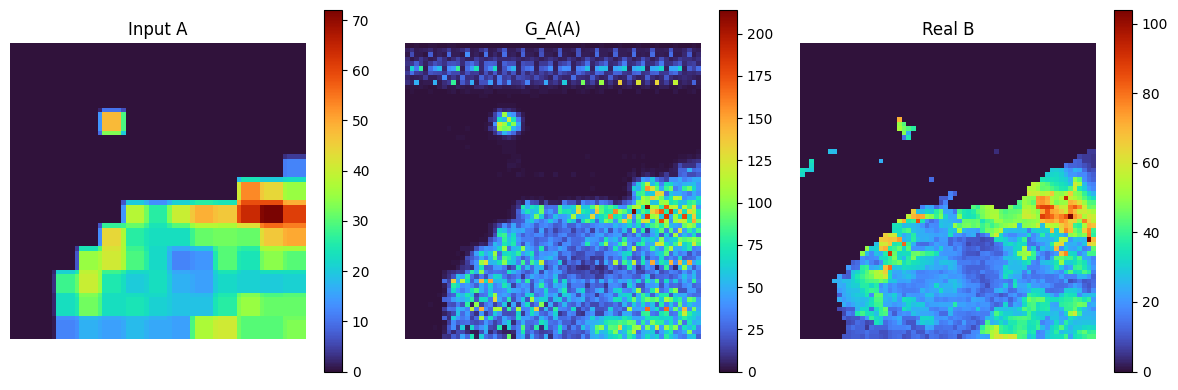

In [44]:
PRECIPITATION_CHANNEL = 2
G_A.eval()
with torch.inference_mode():
    # A, B = next(iter(dataloader))
    for A, B in dataloader:
        real_A = A.to(device)
        real_B = B.to(device)
        fake_B = G_A(real_A)
        rec_A = G_B(fake_B)
        
        img_in = Image.fromarray(tensor2im(A)).convert("L")
        img_fake = Image.fromarray(tensor2im(fake_B)).convert("L")
        img_rec = Image.fromarray(tensor2im(rec_A)).convert("L")
        real_B = Image.fromarray(tensor2im(real_B)).convert("L")

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        fig = axs[0].imshow(img_in, cmap="turbo"); axs[0].set_title("Input A")
        plt.colorbar(fig, ax=axs[0])
        fig = axs[1].imshow(img_fake, cmap="turbo"); axs[1].set_title("G_A(A)")
        plt.colorbar(fig, ax=axs[1])
        fig = axs[2].imshow(real_B, cmap="turbo"); axs[2].set_title("Real B")
        plt.colorbar(fig, ax=axs[2])
        for ax in axs: ax.axis("off")
        plt.tight_layout()
        break